In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Implementation of Adversarial Search (MINIMAX) using Python Libraries

Optimal value: 12


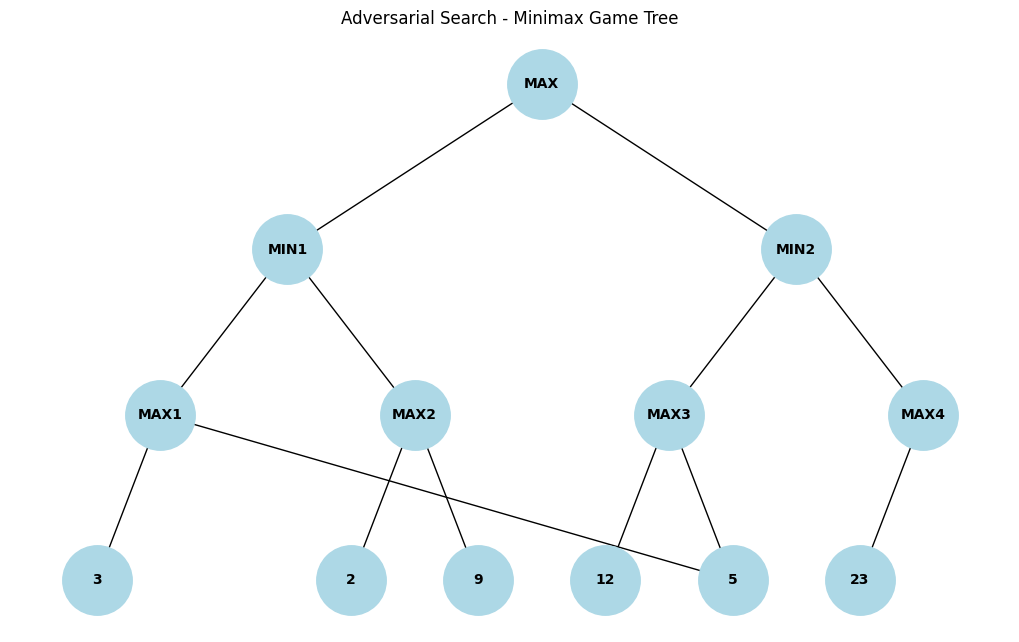

In [1]:
import math
import networkx as nx
import matplotlib.pyplot as plt

# Minimax Algorithm
def minimax(depth, node_index, maximizing_player, values, height):

    # Base case: Leaf node
    if depth == height:
        return values[node_index]

    # MAX player's turn
    if maximizing_player:
        left = minimax(depth + 1, node_index * 2, False, values, height)
        right = minimax(depth + 1, node_index * 2 + 1, False, values, height)
        return max(left, right)

    # MIN player's turn
    else:
        left = minimax(depth + 1, node_index * 2, True, values, height)
        right = minimax(depth + 1, node_index * 2 + 1, True, values, height)
        return min(left, right)


# Leaf node values
values = [3, 5, 2, 9, 12, 5, 23, 23]

# Height of game tree
height = int(math.log2(len(values)))

# Find optimal value
result = minimax(0, 0, True, values, height)

print("Optimal value:", result)


# ---------------- GRAPH ----------------

# Create directed graph
G = nx.DiGraph()

# Add edges of game tree
edges = [
    ("MAX", "MIN1"), ("MAX", "MIN2"),
    
    ("MIN1", "MAX1"), ("MIN1", "MAX2"),
    ("MIN2", "MAX3"), ("MIN2", "MAX4"),

    ("MAX1", "3"), ("MAX1", "5"),
    ("MAX2", "2"), ("MAX2", "9"),
    ("MAX3", "12"), ("MAX3", "5"),
    ("MAX4", "23"), ("MAX4", "23")
]

G.add_edges_from(edges)

# Positions of nodes
pos = {
    "MAX": (3.5, 3),

    "MIN1": (1.5, 2),
    "MIN2": (5.5, 2),

    "MAX1": (0.5, 1),
    "MAX2": (2.5, 1),
    "MAX3": (4.5, 1),
    "MAX4": (6.5, 1),

    "3": (0, 0),
    "5": (1, 0),
    "2": (2, 0),
    "9": (3, 0),
    "12": (4, 0),
    "5": (5, 0),
    "23": (6, 0)
}

# Draw graph
plt.figure(figsize=(10, 6))

nx.draw(
    G, pos,
    with_labels=True,
    node_size=2500,
    node_color="lightblue",
    font_size=10,
    font_weight="bold",
    arrows=False
)

plt.title("Adversarial Search - Minimax Game Tree")
plt.show()